In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set_theme(style="whitegrid")
# Ensure the path is correct for your 'data' folder
df = pd.read_csv('data/netflix_titles.csv')
print("Cell 1: Data Loaded Successfully")

Cell 1: Data Loaded Successfully


In [22]:
# Strip whitespace and convert date safely
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

# Extract features
df['year_added'] = df['date_added'].dt.year.fillna(0).astype(int)
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
df['primary_country'] = df['country'].fillna('Unknown').apply(lambda x: x.split(',')[0])

print("Cell 2: Data cleaned and features extracted successfully.")

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Mastawal\AppData\Local\Temp\ipykernel_15100\407324958.py:7: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


Cell 2: Data cleaned and features extracted successfully.


In [23]:
# Create the variables that will be used in the visualization
# This is where 'ct' is defined
ct = pd.crosstab(df['listed_in'].str.split(',').str[0], df['rating'], normalize='index')

# Run other advanced analytics
corr = df[['year_added', 'duration_num']].corr()
age_percentiles = df['release_year'].quantile([0.5, 0.9])
cohorts = df.groupby(['year_added', 'type']).size().unstack()

print("Cell 3: Analysis Variables Defined (ct, corr, cohorts, etc.)")

Cell 3: Analysis Variables Defined (ct, corr, cohorts, etc.)


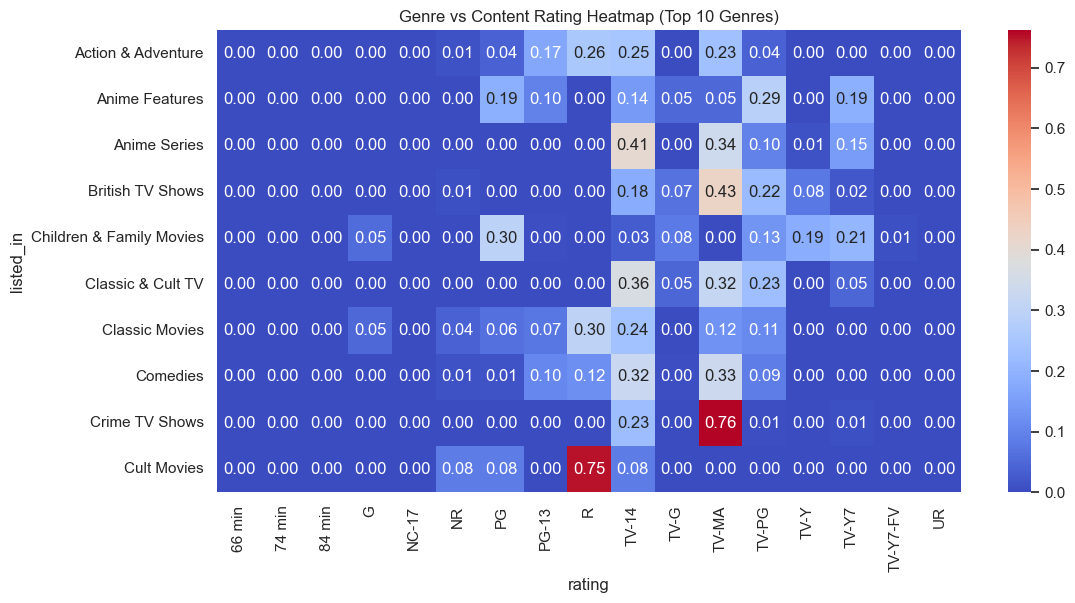

Cell 4: Visualization Rendered


In [24]:
# Now that 'ct' is defined in Cell 3, this will work perfectly
plt.figure(figsize=(12, 6))
sns.heatmap(ct.iloc[:10, :], annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Genre vs Content Rating Heatmap (Top 10 Genres)")
plt.show()
print("Cell 4: Visualization Rendered")